In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, norm
from scipy import stats

In [2]:
# Load the datasets
try:
    train = pd.read_csv('dataset.csv')
    test = pd.read_csv('test.csv')
except FileNotFoundError:
    print("Ensure 'dataset.csv' and 'test.csv' are in the same directory.")
    # Handle error appropriately

In [3]:
# Display the first few rows of the training data
print("Training Data:")
print(train.head())

# Display information about the training data
print("\nTraining Data Info:")
train.info()

# Display descriptive statistics for the training data
print("\nTraining Data Description:")
print(train.describe())

Training Data:
   id   sale_date  sale_price  sale_nbr sale_warning join_status  join_year  \
0   0  2014-11-15      236000       2.0                    nochg       2025   
1   1  1999-01-15      313300       NaN          26        nochg       2025   
2   2  2006-08-15      341000       1.0                    nochg       2025   
3   3  1999-12-15      267000       1.0                    nochg       2025   
4   4  2018-07-15     1650000       2.0                   miss99       2025   

   latitude  longitude  area  ... view_olympics view_cascades  \
0   47.2917  -122.3658    53  ...             0             0   
1   47.6531  -122.1996    74  ...             0             0   
2   47.4733  -122.1901    30  ...             0             0   
3   47.4739  -122.3295    96  ...             0             0   
4   47.7516  -122.1222    36  ...             0             0   

  view_territorial  view_skyline  view_sound  view_lakewash  view_lakesamm  \
0                0             0         

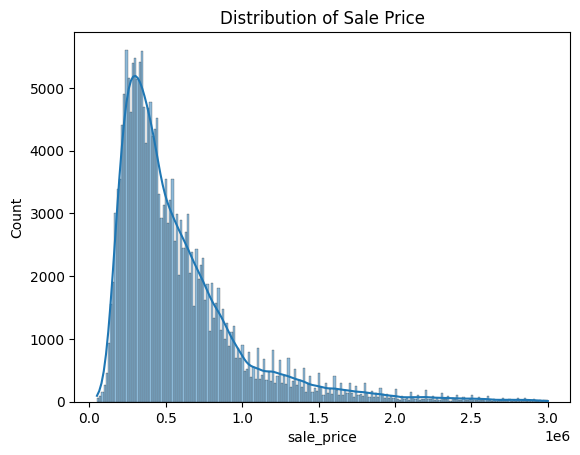

Skewness: 2.092406
Kurtosis: 5.665742


In [4]:
# Plot the distribution of the sale price
sns.histplot(train['sale_price'], kde=True)
plt.title('Distribution of Sale Price')
plt.show()

# Calculate the skewness and kurtosis
print("Skewness: %f" % train['sale_price'].skew())
print("Kurtosis: %f" % train['sale_price'].kurt())

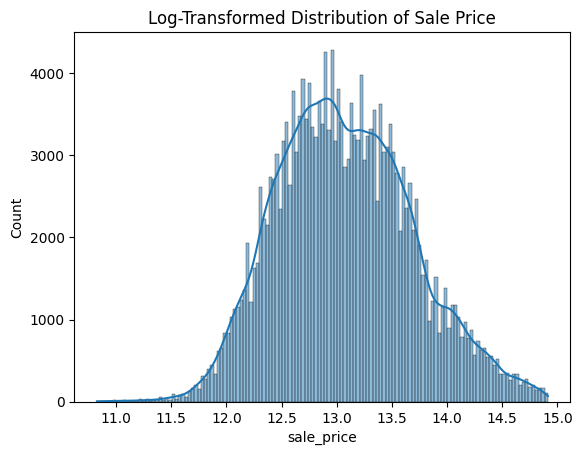

In [5]:
# Apply a log transformation to the sale price
train['sale_price'] = np.log1p(train['sale_price'])

# Plot the new distribution
sns.histplot(train['sale_price'], kde=True)
plt.title('Log-Transformed Distribution of Sale Price')
plt.show()

In [8]:
# The correct column name is 'sale_date'
date_column = 'sale_date'

print(f"Processing '{date_column}' column...")
# Convert to datetime objects
train[date_column] = pd.to_datetime(train[date_column])
test[date_column] = pd.to_datetime(test[date_column])

# --- Feature Engineering from Dates ---
# Extracting year and month can capture trends and seasonality
train['sale_year'] = train[date_column].dt.year
train['sale_month'] = train[date_column].dt.month

test['sale_year'] = test[date_column].dt.year
test['sale_month'] = test[date_column].dt.month

# We can also calculate the age of the property at the time of sale
# We'll use a simple approximation, as 'year_built' is just a year
train['property_age'] = train['sale_year'] - train['year_built']
test['property_age'] = test['sale_year'] - test['year_built']

# Now we can drop the original date column and year_built
train = train.drop([date_column, 'year_built'], axis=1)
test = test.drop([date_column, 'year_built'], axis=1)

print("Created 'sale_year', 'sale_month', and 'property_age' features.")
print("Dropped the original 'sale_date' and 'year_built' columns.")

Processing 'sale_date' column...
Created 'sale_year', 'sale_month', and 'property_age' features.
Dropped the original 'sale_date' and 'year_built' columns.


Displaying full correlation heatmap...


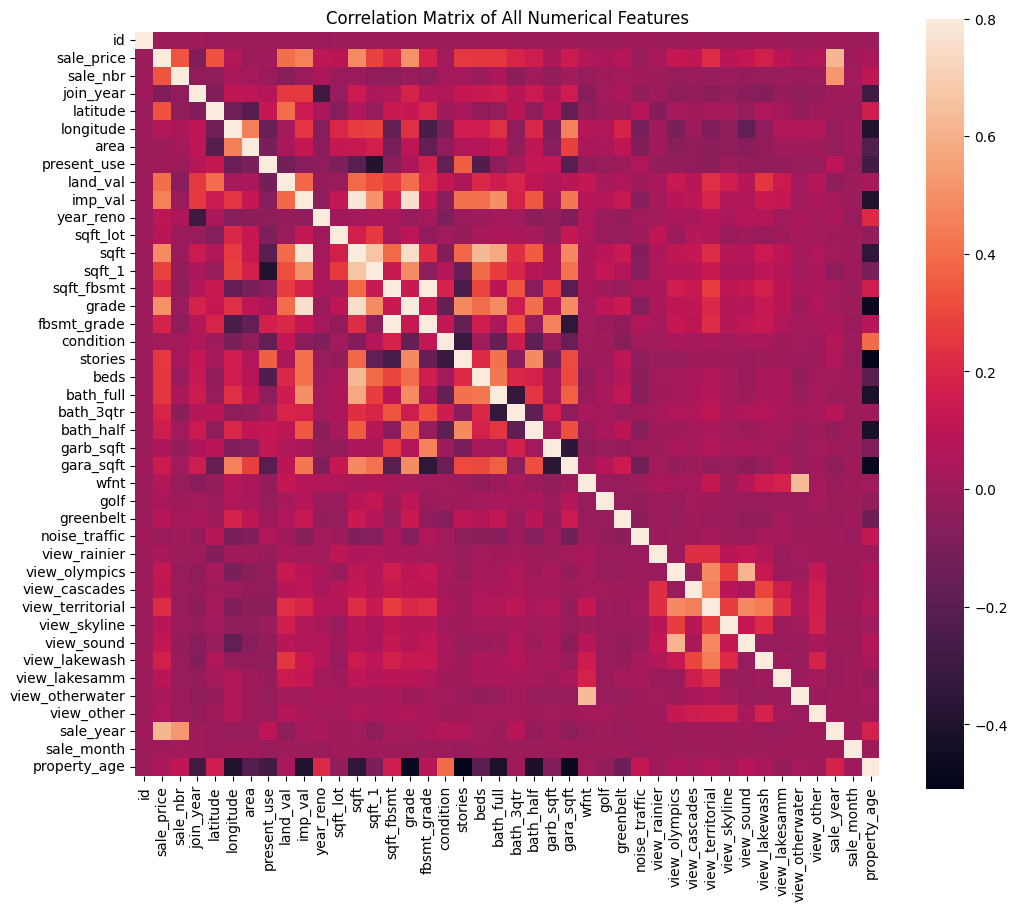


Displaying heatmap of features most correlated with sale_price...


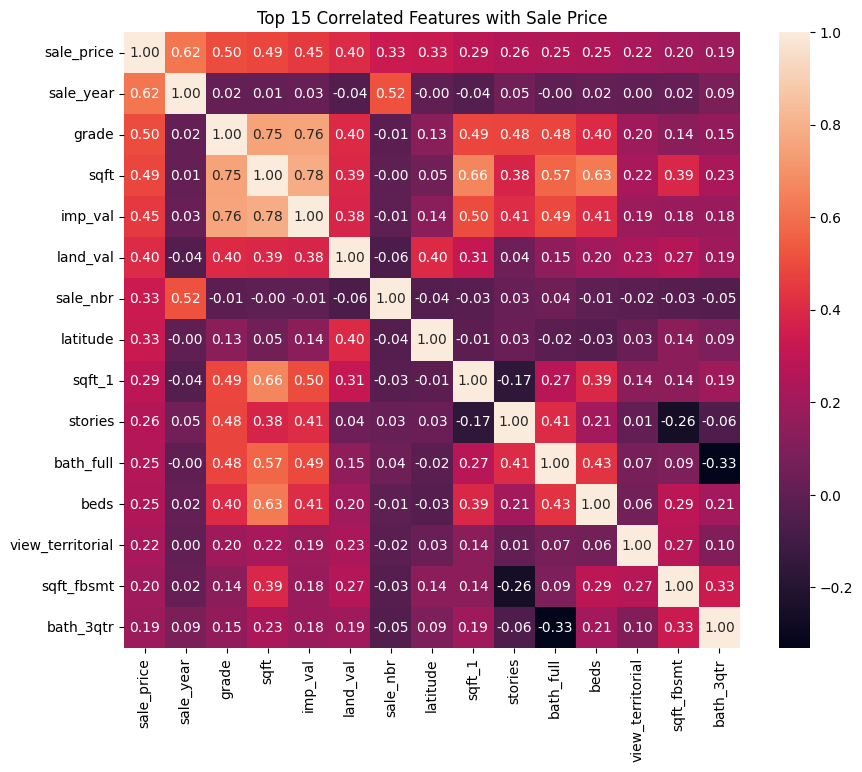

In [9]:
# Select only numeric columns for the correlation matrix
numeric_train = train.select_dtypes(include=np.number)

# Create the full correlation matrix heatmap
print("Displaying full correlation heatmap...")
corrmat = numeric_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.title('Correlation Matrix of All Numerical Features')
plt.show()


# --- Zoomed-in Heatmap for Target Variable ---
# This is more readable and actionable
print("\nDisplaying heatmap of features most correlated with sale_price...")
k = 15 # Let's look at the top 15 features
cols = corrmat.nlargest(k, 'sale_price')['sale_price'].index
cm = numeric_train[cols].corr() # Recalculate correlation on this subset

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
            annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.title(f'Top {k} Correlated Features with Sale Price')
plt.show()

In [10]:
# Calculate and display missing data percentages again after date processing
missing_data = train.isnull().sum().sort_values(ascending=False)
missing_percent = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_info = pd.concat([missing_data, missing_percent], axis=1, keys=['Total Missing', 'Percentage'])
print("Missing Data Report:")
print(missing_info[missing_info['Total Missing'] > 0])

# --- Imputation Strategy ---
# For 'sale_nbr', let's use the median as it's less sensitive to outliers than the mean
train['sale_nbr'].fillna(train['sale_nbr'].median(), inplace=True)
test['sale_nbr'].fillna(test['sale_nbr'].median(), inplace=True) 

# For categorical features, filling with 'None' or the mode is a good start.
# 'None' can act as its own category.
train['subdivision'].fillna('None', inplace=True)
test['subdivision'].fillna('None', inplace=True)
train['submarket'].fillna(train['submarket'].mode()[0], inplace=True) # Use mode for submarket
test['submarket'].fillna(test['submarket'].mode()[0], inplace=True)

print("\nMissing data has been imputed.")

Missing Data Report:
             Total Missing  Percentage
sale_nbr             42182     21.0910
subdivision          17550      8.7750
submarket             1717      0.8585

Missing data has been imputed.


/tmp/ipykernel_1414/4290334856.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['sale_nbr'].fillna(train['sale_nbr'].median(), inplace=True)
/tmp/ipykernel_1414/4290334856.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

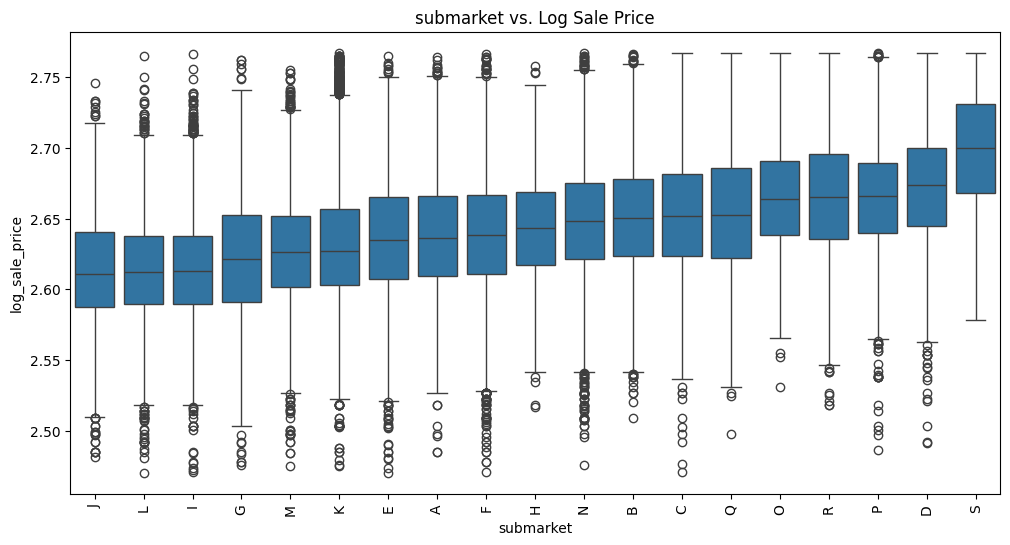

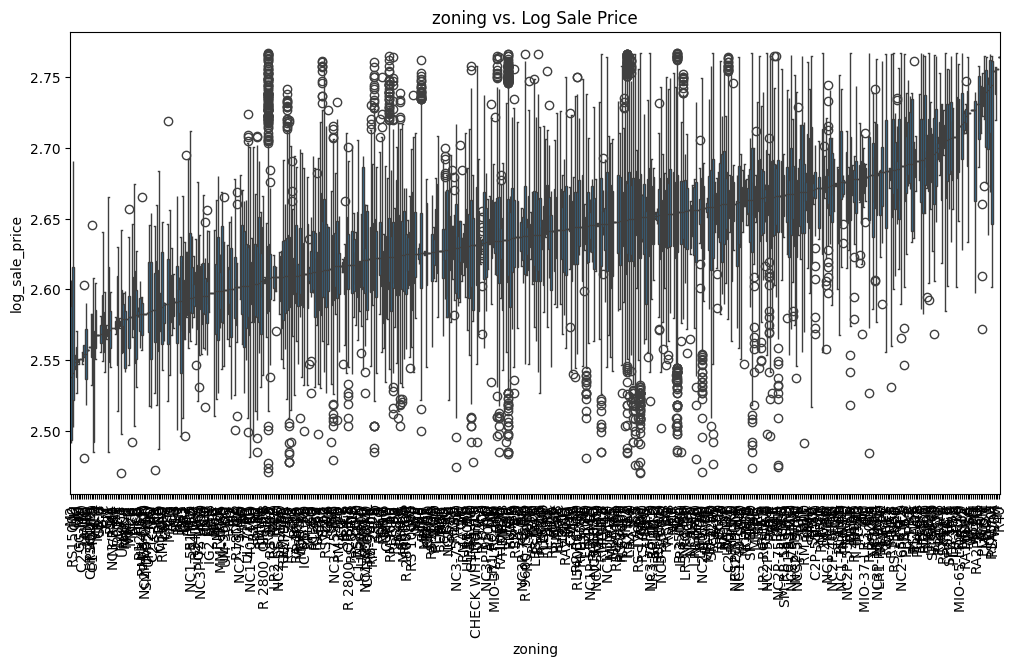

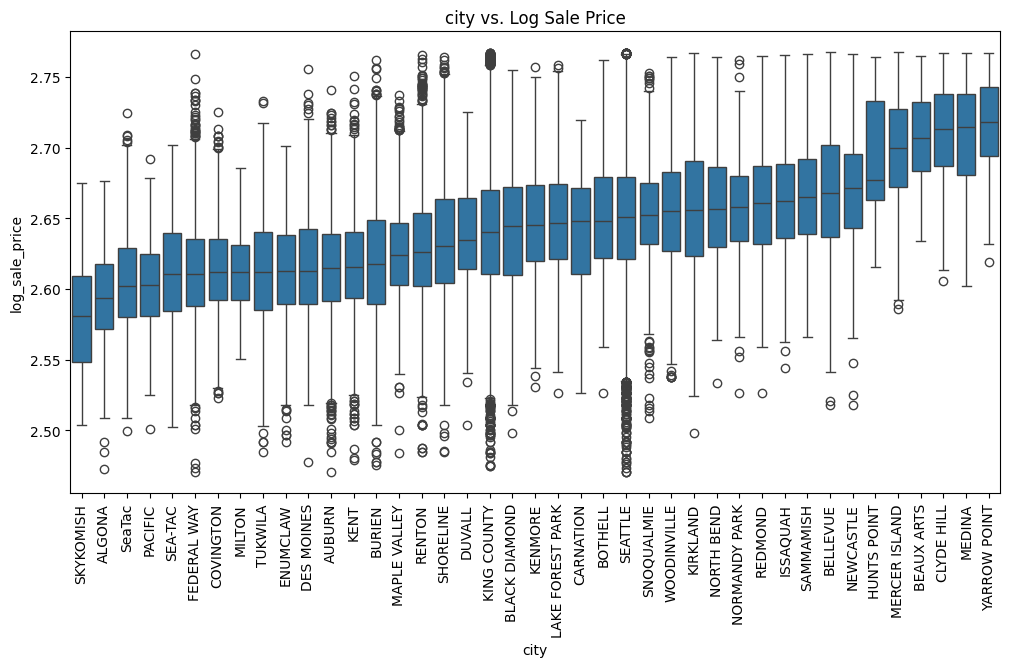

In [11]:
# We'll use the log-transformed sale_price for better visualization
train['log_sale_price'] = np.log1p(train['sale_price'])

# Function to create boxplots for categorical features
def plot_categorical(feature):
    # Order by median sale price for a clearer plot
    order = train.groupby(feature)['log_sale_price'].median().sort_values().index
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=feature, y='log_sale_price', data=train, order=order)
    plt.xticks(rotation=90)
    plt.title(f'{feature} vs. Log Sale Price')
    plt.show()

# Let's check a few key categoricals
plot_categorical('submarket')
plot_categorical('zoning')
plot_categorical('city')

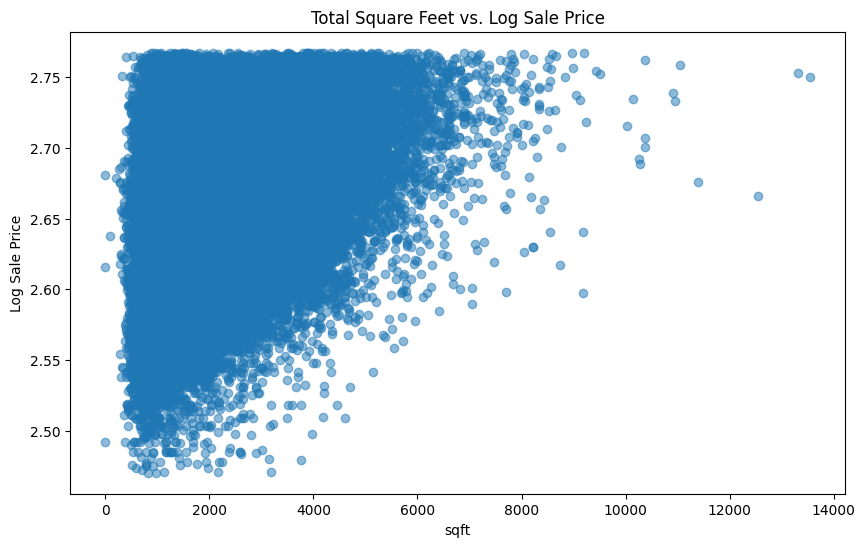

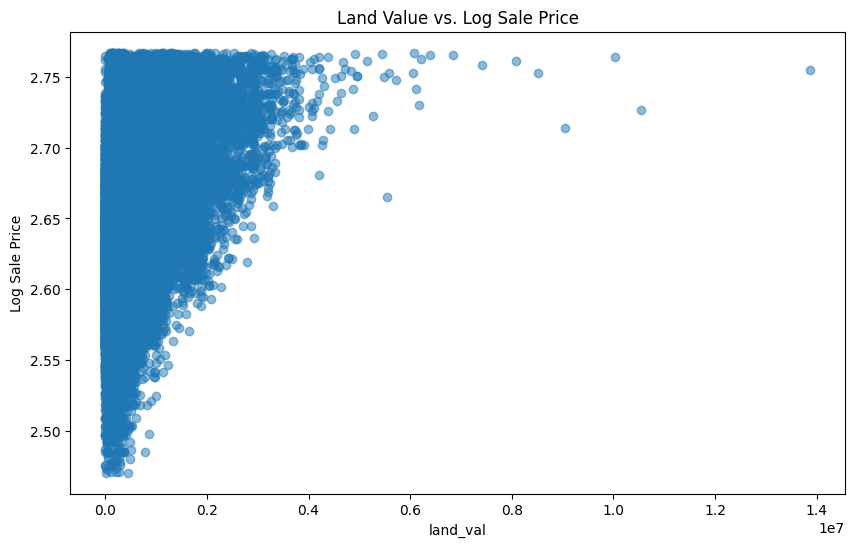

In [13]:
# Scatter plot for sqft vs sale_price
plt.figure(figsize=(10, 6))
plt.scatter(x=train['sqft'], y=train['log_sale_price'], alpha=0.5)
plt.title('Total Square Feet vs. Log Sale Price')
plt.xlabel('sqft')
plt.ylabel('Log Sale Price')
plt.show()

# Scatter plot for land_val vs sale_price
plt.figure(figsize=(10, 6))
plt.scatter(x=train['land_val'], y=train['log_sale_price'], alpha=0.5)
plt.title('Land Value vs. Log Sale Price')
plt.xlabel('land_val')
plt.ylabel('Log Sale Price')
plt.show()

In [14]:
print(f"Number of columns before encoding: {train.shape[1]}")

# Drop the id column and the original (non-log) sale_price
train_ids = train['id']
test_ids = test['id']
train = train.drop(['id', 'sale_price'], axis=1)
test = test.drop(['id'], axis=1) # test data doesn't have sale_price

# One-Hot Encode the data
# This will handle all 'object' type columns
train = pd.get_dummies(train)
test = pd.get_dummies(test)

# Align columns - crucial for consistent features between train and test
train_labels = train['log_sale_price']
train, test = train.align(test, join='inner', axis=1) 
train['log_sale_price'] = train_labels # Add the label back after aligning

print(f"Number of columns after encoding and aligning: {train.shape[1]}")

# Note: The target variable 'log_sale_price' is now at the end of the dataframe.

Number of columns before encoding: 49
Number of columns after encoding and aligning: 10775
